In [ ]:
## Módulo de pré-processamento de dados
# Padronização dos dados numéricos
# Redução de dimensionalidade via PCA
# Análise das cargas fatoriais
# Visualização do PCA 2D

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import json



def carregar_arquivo(caminho):
  """
  0 - DB - Planetary Systems Composite Data

  Carrega a base de dados Planetary Systems Composite Data em formato Excel
  e verifica falha no carregamento.

  Parâmetros
  ----------
  caminho : str
     Caminho do arquivo Excel.

  Retorna
  -------
  pandas.DataFrame
      DataFrame carregado.
  """
  try:
    return pd.read_excel(caminho)
  except FileNotFoundError:
    raise FileNotFoundError("Arquivo não encontrado.")

In [ ]:
def limpeza_dados(df):
  """
  PRÉ-PROCESSAMENTO
  1 - Limpeza de dados
  1.1 - Remoção das Colunas que não serão utilizadas.

  Nesta etapa, todas as linhas da planilha são mantidas.

  Dicionários de variáveis:
  pl_name = Nome do Planeta
  pl_orbper = Período Orbital (Dias)
  pl_orbsmax = Semi-eixo Maior da Órbita
  pl_rade = Raio do Planeta
  pl_bmasse = Massa do Planeta
  pl_orbeccen = Excentricidade Orbital

  Parâmetros
  ----------
  df : pandas.DataFrame
    DataFrame a ser processado.

  Retorna
  ----------
  pandas.DataFrame
    DataFrame processado.
  """

  col_checked = ["pl_name",
                "pl_orbper","pl_orbpererr1","pl_orbpererr2","pl_orbperlim",
                "pl_orbsmax","pl_orbsmaxerr1","pl_orbsmaxerr2","pl_orbsmaxlim",
                "pl_rade","pl_radeerr1","pl_radeerr2","pl_radelim",
                "pl_bmasse","pl_bmasseerr1","pl_bmasseerr2","pl_bmasselim",
                "pl_orbeccen","pl_orbeccenerr1","pl_orbeccenerr2","pl_orbeccenlim"]

  return df[col_checked]

In [ ]:
def def_lines_limits(df_columns_filter):
  """
  1.2 - Remoção das Linhas de limites diferentes de 0, -1 e 1.

  Nesta etapa, deixam-se apenas as linhas que contém valores confirmados ou estimados com precisão e/ou
  aqueles estimados com grau de incerteza inferior a 50%.

  Descrição de variáveis:
  pl_orbperlim = Limite da distância máxima da estrela host
  pl_orbsmaxlim = Limite do semi-eixo maior da órbita
  pl_radelim = Limite do raio do planeta
  pl_bmasselim = Limite da massa do planeta
  pl_orbeccenlim = Limite da excentricidade orbital

  Parâmetros
  ----------
  df_columns_filter : pandas.DataFrame
    DataFrame a ser processado.

  Retorna
  ----------
  df_lim: pandas.DataFrame
    DataFrame processado.
  """

  df_lim = df_columns_filter[
      (df_columns_filter['pl_orbperlim'].isin([0, 1, -1])) &
      (df_columns_filter['pl_orbsmaxlim'].isin([0, 1, -1])) &
      (df_columns_filter['pl_radelim'].isin([0, 1, -1])) &
      (df_columns_filter['pl_bmasselim'].isin([0, 1, -1])) &
      (df_columns_filter['pl_orbeccenlim'].isin([0, 1, -1]))
  ]

  return df_lim

In [ ]:
def remocao_incertezas(df_lines_limits):
  """
  1.3 - Remoção das Linhas de alta incerteza.

  Eliminam-se as linhas que contêm grau de incerteza superior a 50%.

  Critérios
  ---------
  - Valores == 0 são considerados precisos, não sendo necessário verificar incerteza.
  - Valores != 0 devem apresentar incerteza relativa ≤ 50%.

  Parâmetros
  ----------
  df_lim : pandas.DataFrame
      DataFrame a ser processado.

  Retorna
  -------
  pandas.DataFrame
      DataFrame processado.
  """

  df_inc = df_lines_limits[
      (
        (df_lines_limits['pl_orbperlim'] == 0) |
         (
            (df_lines_limits['pl_orbper'] != 0) &
            (df_lines_limits['pl_orbpererr1'].abs() / df_lines_limits['pl_orbper'].abs() <= 0.5) &
            (df_lines_limits['pl_orbpererr2'].abs() / df_lines_limits['pl_orbper'].abs() <= 0.5)
        )
      )
      &
      (
        (df_lines_limits['pl_orbsmaxlim'] == 0) |
        (
            (df_lines_limits['pl_orbsmax'] != 0) &
            (df_lines_limits['pl_orbsmaxerr1'].abs() / df_lines_limits['pl_orbsmax'].abs() <= 0.5) &
            (df_lines_limits['pl_orbsmaxerr2'].abs() / df_lines_limits['pl_orbsmax'].abs() <= 0.5)
        )
      )
      &
      (
        (df_lines_limits['pl_bmasselim'] == 0) |
        (
            (df_lines_limits['pl_bmasse'] != 0) &
            (df_lines_limits['pl_bmasseerr1'].abs() / df_lines_limits['pl_bmasse'].abs() <= 0.5) &
            (df_lines_limits['pl_bmasseerr2'].abs() / df_lines_limits['pl_bmasse'].abs() <= 0.5)
        )
      )
      &
      (
        (df_lines_limits['pl_radelim'] == 0) |
        (
            (df_lines_limits['pl_rade'] != 0) &
            (df_lines_limits['pl_radeerr1'].abs() / df_lines_limits['pl_rade'].abs() <= 0.5) &
            (df_lines_limits['pl_radeerr2'].abs() / df_lines_limits['pl_rade'].abs() <= 0.5)
        )
      )
      &
      (
        (df_lines_limits['pl_orbeccenlim'] == 0) |
        (
            (df_lines_limits['pl_orbeccen'] != 0) &
            (df_lines_limits['pl_orbeccenerr1'].abs() / df_lines_limits['pl_orbeccen'].abs() <= 0.5) &
            (df_lines_limits['pl_orbeccenerr2'].abs() / df_lines_limits['pl_orbeccen'].abs() <= 0.5)
        )
      )
  ]

  return df_inc

In [ ]:
def id_outliers(df_inc_rm):
  """
  1.4 - Identificação dos Outliers

  Método
  ----------
  - Define o tamanho da figura (polegadas)
  - Remove valores NaN para evitar erros
  - Cria um boxplot para cada coluna numérica
  - Define um grid para visualização (0.6 = 60% opaco)

  Critérios
  ----------
  Cada boxplot sumariza a distribuição dos dados através de:
  [Q1 - 1.5×IQR, Q3 + 1.5×IQR], onde IQR = Q3 - Q1.

  - Linha central: mediana (Q2)
  - Caixa: intervalo interquartil (IQR = Q3 - Q1)
  - Whiskers: estendem-se até 1.5×IQR após os quartis Q1 e Q3
  - Pontos além dos whiskers: outliers estatísticos (valores atípicos)

  Parâmetros
  ----------
  df_inc_rm : pandas.DataFrame
      DataFrame a ser processado.

  Retorna
  -------
  none
      A função apenas exibe os boxplots.
  """
  col_keep = ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "pl_orbeccen"]

  col_names = {
      "pl_orbper": "Período Orbital do Planeta",
      "pl_orbsmax": "Semi-eixo Maior da Órbita",
      "pl_rade": "Raio do Planeta",
      "pl_bmasse": "Massa do Planeta",
      "pl_orbeccen": "Excentricidade Orbital"
  }

  for col in col_keep:
        if col not in df_inc_rm.columns:
            raise KeyError(f"Coluna '{col}' não encontrada no DataFrame.")

  for col in col_keep:
      plt.figure(figsize=(6, 4))
      plt.boxplot(df_inc_rm[col].dropna())
      plt.title(f'Boxplot - {col_names[col]}', fontsize=12, fontweight='bold')
      plt.ylabel('Valores Normalizados')
      plt.xlabel(col_names[col])
      plt.grid(True, linestyle='--', alpha=0.6)
      plt.tight_layout()  # Ajusta automaticamente os espaços para evitar cortes
      plt.show()
      print("\n")

  return None

In [ ]:
def rm_outliers(df_inc_rm):
  """
  Identificação das linhas que contém os outliers - Método IQR - utilizado no boxplot

  Método
  ---------
  - Inicializa a condição como False (nenhum outlier inicialmente)
  - Para cada coluna, calcula IQR e atualiza a condição
  - Mantém apenas os pontos DENTRO dos limites (não outliers)
  - Filtra o DataFrame original (mantém apenas linhas sem outliers em NENHUMA coluna)

  Observação:
  Como parte implícita dessa função todas as linhas que contenham valores NaN
  (Not a Number) em qualquer uma das variáveis analisadas
  são automaticamente removidas do dataset.

  Parâmetros
  ----------
  di_inc_rm : pandas.DataFrame
      DataFrame a ser processado.

  Retorna
  -------
  pandas.DataFrame
    DataFrame filtrado, contendo apenas linhas sem outliers em nenhuma
    das variáveis analisadas

  """
  col_keep = ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "pl_orbeccen"]
  cond = pd.Series(True, index=df_inc_rm.index)

  for coluna in col_keep:
      Q1 = df_inc_rm[coluna].quantile(0.25)
      Q3 = df_inc_rm[coluna].quantile(0.75)
      IQR = Q3 - Q1
      cond &= (df_inc_rm[coluna] >= Q1 - 1.5 * IQR) & (df_inc_rm[coluna] <= Q3 + 1.5 * IQR)
  df_inc_rm = df_inc_rm[cond]

  return df_inc_rm

In [ ]:
def pca_standard_scaler(df_inc_rm, n_components=2):
  """
  2 - NORMALIZAÇÃO/PADRONIZAÇÃO DE DADOS

  Esta etapa realiza a seleção das variáveis numéricas, a padronização
  dos dados utilizando o método StandardScaler e a aplicação da técnica
  de redução de dimensionalidade PCA, com foco nos dois primeiros
  componentes principais

  Método
  ----------
  - Seleção das colunas numéricas
  - Aplicação do StandardScaler
  - Aplicação do PCA
  - Análise da Variância Explicada

  Parâmetros
  ----------
  df_inc_rm : pandas.DataFrame
      DataFrame a ser processado.

  Retorna
  -------
  df_to_hc: pandas.DataFrame
      DataFrame com os dados padronizados e reduzidos.

  pca_std: sklearn.decomposition.PCA
      Objeto PCA ajustado sobre os dados padronizados.

  colunas_numericas: list of str
      Lista com os nomes das variáveis numéricas utilizadas no PCA.

  variancia_pc1: float
      Variância explicada pelo PC1.

  variancia_pc2: float
      Variância explicada pelo PC2.
  """
  colunas_numericas = ["pl_orbper", "pl_orbsmax", "pl_rade", "pl_bmasse", "pl_orbeccen"]
  df_numerico = df_inc_rm[colunas_numericas].copy()

  scaler = StandardScaler()
  df_normalizado = scaler.fit_transform(df_numerico)

  pca_std = PCA(n_components)
  df_pca = pca_std.fit_transform(df_normalizado)

  df_to_hc = pd.DataFrame(df_pca, columns=['PC1', 'PC2'], index=df_inc_rm.index)

  df_std = pd.DataFrame( df_normalizado, columns=colunas_numericas,index=df_inc_rm.index)

  df_to_hc = pd.concat([df_to_hc, df_std], axis=1)

  variancia_pc1, variancia_pc2 = pca_std.explained_variance_ratio_
  variancia_total = variancia_pc1 + variancia_pc2

  print("Análise PCA:")
  print(f"Variância explicada total: {variancia_total:.1%}")
  print(f"PC1: {variancia_pc1:.1%} | PC2: {variancia_pc2:.1%}")

  print("\nCOLUNAS EM df_to_hc:")
  print(df_to_hc.columns.tolist())

  return df_to_hc, pca_std, scaler, colunas_numericas, variancia_pc1, variancia_pc2

In [ ]:
def ranges_terrestres(scaler, colunas_numericas,caminho_rgjson):
    """
    3.4 Referencial Terrestre no Espaço Padronizado
    ===============================================

    Define os ranges físicos característicos de planetas terrestres
    e os converte para o espaço padronizado (z-score).

    Parameters
    ----------
    scaler : StandardScaler
        Scaler ajustado aos dados físicos originais.

    Returns
    -------
    ranges_padronizados : dict
        Ranges terrestres no espaço padronizado.
    """

    if not hasattr(scaler, "mean_"):
        raise ValueError("Scaler precisa estar ajustado antes de usar esta função.")

    ranges_fisicos = {
        "pl_orbper": (88, 687),
        "pl_orbsmax": (0.39, 1.52),
        "pl_rade": (0.5, 1.6),
        "pl_bmasse": (1, 15),
        "pl_orbeccen": (0, 0.25)
    }

    ranges_padronizados = {}

    for var, (low, high) in ranges_fisicos.items():

        idx = colunas_numericas.index(var)

        mean = scaler.mean_[idx]
        std = scaler.scale_[idx]

        low_z = (low - mean) / std
        high_z = (high - mean) / std

        ranges_padronizados[var] = (low_z, high_z)

    with open(caminho_rgjson, "w") as f:
      json.dump(ranges_padronizados, f, indent=4)

    print("\nRANGES TERRESTRES NO ESPAÇO PADRONIZADO:")
    for var, (lo, hi) in ranges_padronizados.items():
        print(f"{var}: {lo:.5f} – {hi:.5f}")

    return ranges_padronizados

In [ ]:
def analise_cargas(pca_std, colunas_numericas):
    """
    2.7 – Análise das cargas (loadings) e contribuição das variáveis no PCA.

    Esta etapa calcula as cargas fatoriais (loadings) das variáveis originais
    em cada componente principal e estima a contribuição percentual de cada
    variável nos dois primeiros componentes (PC1 e PC2).

    Além disso, é calculada a contribuição acumulada das três variáveis
    mais relevantes em cada componente.

    Parâmetros
    ----------
    pca_std : sklearn.decomposition.PCA
        Objeto PCA já ajustado sobre os dados padronizados.

    colunas_numericas : list of str
        Lista com os nomes das variáveis numéricas utilizadas no PCA.

    Retorna
    -------
    df_loadings : pandas.DataFrame
        DataFrame contendo as cargas fatoriais das variáveis para PC1 e PC2.

    contrib_pc1 : pandas.Series
        Contribuição percentual de cada variável para o PC1.

    contrib_pc2 : pandas.Series
        Contribuição percentual de cada variável para o PC2.

    soma_top3_pc1 : float
        Soma da contribuição percentual das três variáveis mais relevantes no PC1.

    soma_top3_pc2 : float
        Soma da contribuição percentual das três variáveis mais relevantes no PC2.
    """

    # 2.7 – Cálculo das cargas fatoriais (loadings)
    loadings = pca_std.components_.T * np.sqrt(pca_std.explained_variance_)
    df_loadings = pd.DataFrame(loadings, index=colunas_numericas, columns=['PC1', 'PC2'])

    # 2.7.1 – Contribuição percentual de cada variável
    contrib_pc1 = (df_loadings['PC1'].abs()/ df_loadings['PC1'].abs().sum() * 100).round(1)

    contrib_pc2 = (df_loadings['PC2'].abs()/ df_loadings['PC2'].abs().sum() * 100).round(1)

    # 2.7.2 – Ordenação por contribuição
    contrib_pc1_sorted = contrib_pc1.sort_values(ascending=False)
    contrib_pc2_sorted = contrib_pc2.sort_values(ascending=False)

    # 2.7.3 – Seleção das três variáveis mais relevantes
    top3_pc1 = contrib_pc1_sorted.head(3)
    top3_pc2 = contrib_pc2_sorted.head(3)

    # 2.7.4 – Contribuição acumulada
    soma_top3_pc1 = top3_pc1.sum()
    soma_top3_pc2 = top3_pc2.sum()

    return (df_loadings, top3_pc1, top3_pc2, soma_top3_pc1, soma_top3_pc2)

In [ ]:
def pca_plot_2D(df_to_hc, variancia_pc1, variancia_pc2, top3_pc1, top3_pc2, soma_top3_pc1, soma_top3_pc2):
  """
  2.7.5 – Visualização do PCA 2D

  Esta função cria um gráfico de dispersão 2D com os dados tratados.

  Paramêtros
  ----------
  df_to_hc : pandas.DataFrame
      DataFrame contendo os dados

  varianca_pc1 : float
      Variância explicada pelo PC1.

  varianca_pc2 : float
      Variância explicada pelo PC2.

  top3_pc1: pandas.Series
      Contribuição percentual das três variáveis mais relevantes no PC1.

  top3_pc2 : pandas.Series
      Contribuição percentual das três variáveis mais relevantes no PC2.

  soma_top3_pc1 : float
      Soma da contribuição percentual das três variáveis mais relevantes no PC1.

  soma_top3_pc2 : float
      Soma da contribuição percentual das três variáveis mais relevantes no PC2.

  Retorna
  --------
  none
      função apenas exibe o gráfico.
  """

  ## 2.9 - Visualização do PCA 2D COM CONTRIBUIÇÃO ACUMULADA
  plt.figure(figsize=(9, 7))
  plt.scatter(df_to_hc['PC1'], df_to_hc['PC2'],  alpha=0.6, s=25, color='hotpink')
  plt.title('Análise de Componentes Principais (PCA) - Exoplanetas', fontsize=12, fontweight='bold', pad=15)

  ##2.10 Labels com contribuição acumulada das top 3 variáveis
  plt.xlabel(f'PC1 ({variancia_pc1:.1%} var.)\n{", ".join(top3_pc1.index)} = {soma_top3_pc1}%', fontsize=10)
  plt.ylabel(f'PC2 ({variancia_pc2:.1%} var.)\n{", ".join(top3_pc2.index)} = {soma_top3_pc2}%', fontsize=10)
  plt.grid(True, linestyle='--', alpha=0.3)
  plt.tight_layout()
  plt.show()

  return None

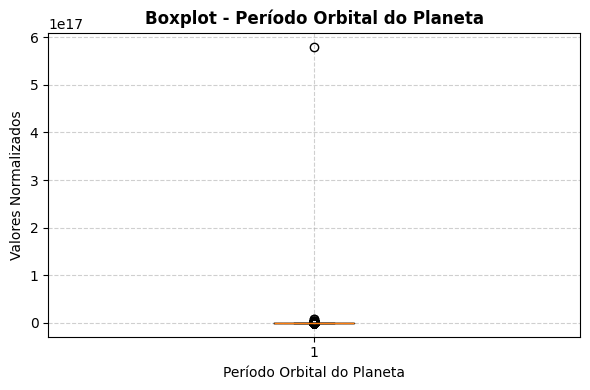

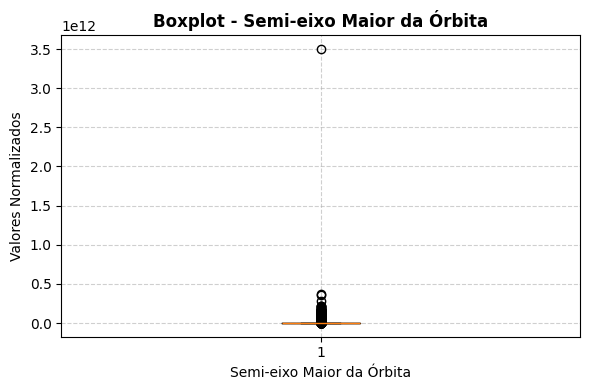

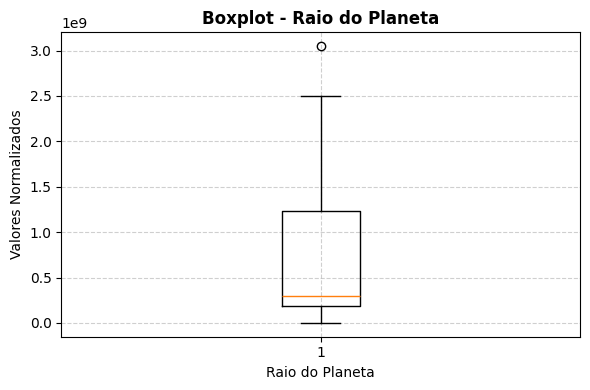

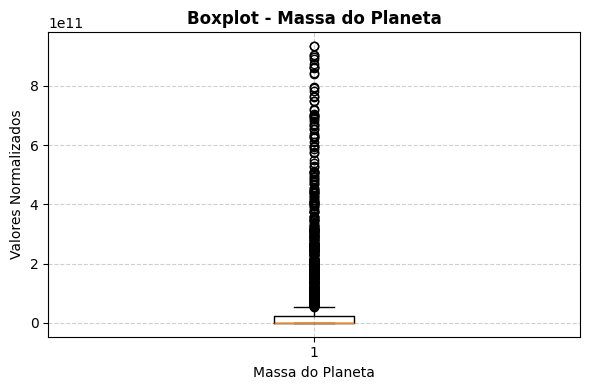

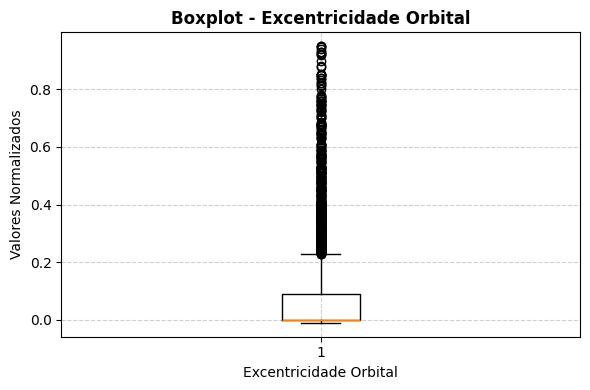



Análise PCA:
Variância explicada total: 77.3%
PC1: 42.4% | PC2: 34.9%

COLUNAS EM df_to_hc:
['PC1', 'PC2', 'pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_orbeccen']

RANGES TERRESTRES NO ESPAÇO PADRONIZADO:
pl_orbper: -0.78281 – -0.78281
pl_orbsmax: 3.03719 – 15.32806
pl_rade: -0.94667 – -0.94667
pl_bmasse: -0.44784 – -0.44784
pl_orbeccen: -0.41672 – 5.25286


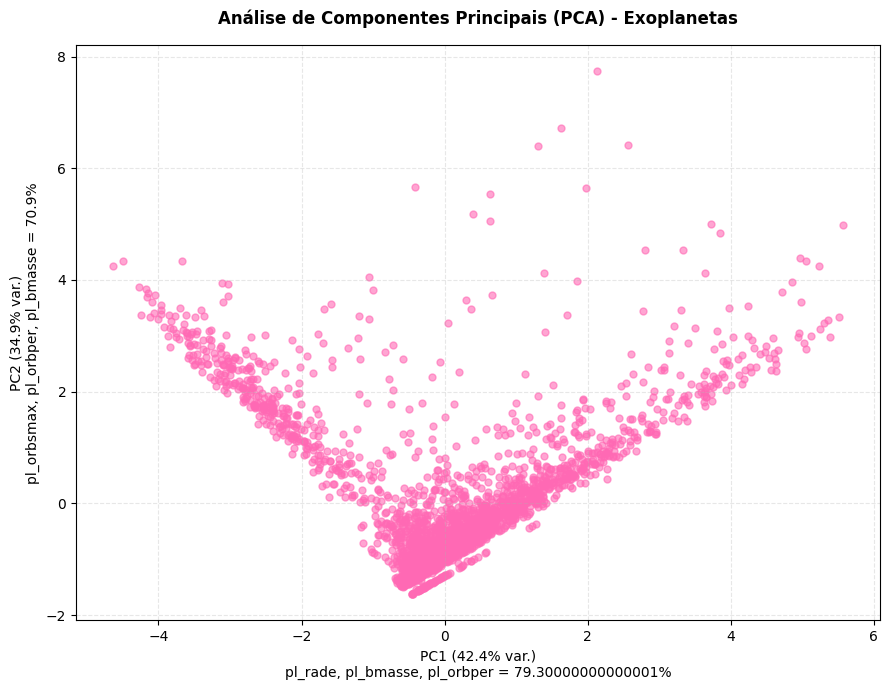

In [ ]:
def main(caminho_entrada, caminho_saida, caminho_rgjson):
    df = carregar_arquivo(caminho_entrada)

    df_columns_filter = limpeza_dados(df)
    df_lines_limits = def_lines_limits(df_columns_filter)
    df_inc_rm = remocao_incertezas(df_lines_limits)

    id_outliers(df_inc_rm)
    df_sem_outliers = rm_outliers(df_inc_rm)


    (
        df_to_hc,
        pca_std,
        scaler,
        colunas_numericas,
        variancia_pc1,
        variancia_pc2
    ) = pca_standard_scaler(df_sem_outliers)

    (
        df_loadings,
        top3_pc1,
        top3_pc2,
        soma_top3_pc1,
        soma_top3_pc2
    ) = analise_cargas(pca_std, colunas_numericas)

    ranges_terrestres(scaler, colunas_numericas, caminho_rgjson)

    pca_plot_2D(
        df_to_hc,
        variancia_pc1,
        variancia_pc2,
        top3_pc2,
        top3_pc1,
        soma_top3_pc1,
        soma_top3_pc2
    )
    df_to_hc["pl_name"] = df.loc[df_to_hc.index, "pl_name"]
    df_to_hc.to_excel(caminho_saida, index=False)

if __name__ == "__main__":
    main(
        caminho_entrada="PSCompData.xlsx",
        caminho_saida="DFHierarchicalCLustering.xlsx",
        caminho_rgjson="ranges_terrestres.json"
    )